# Python Functions

A **function** is a named, reusable block of code — write the logic once, call it as many times as needed. This follows the **DRY principle** (Don't Repeat Yourself): instead of copy-pasting the same code everywhere, define it once and call it by name.

Python has two categories:
- **Built-in functions** — ship with Python itself: `range()`, `len()`, `type()`, `input()`, ...
- **User-defined functions** — written by you, with `def`.

This notebook covers defining, calling, documenting, returning from, and scoping functions, all four argument styles, recursion, and lambda/`filter`/`map`/`reduce`.

## Creating a Function

```
def function_name(parameter1, parameter2):
    # function body
    return value
```

No curly braces — INDENTATION alone defines the function body. `def` is mandatory; `return` is optional.

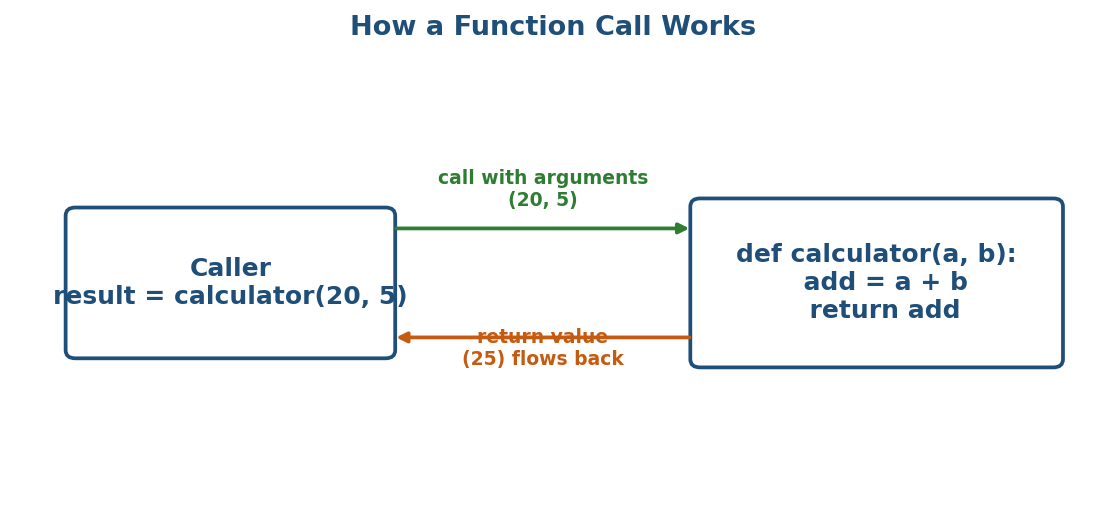

### A Function With No Parameters

In [ ]:
def message():

    print("Welcome to PYnative")



message()

### A Function With Parameters

In [ ]:
def course_func(name, course_name):

    print("Hello", name, "Welcome to PYnative")

    print("Your course name is", course_name)



course_func('John', 'Python')

### A Function With Parameters AND a Return Value

In [ ]:
def calculator(a, b):

    add = a + b

    return add



res = calculator(20, 5)

print("Addition :", res)

## Calling a Function

Use the function's name followed by parentheses, with any required arguments inside.

In [ ]:
def even_odd(n):

    if n % 2 == 0:

        print('Even number')

    else:

        print('Odd Number')



even_odd(19)

### Calling a Function From a Module

In [ ]:
from random import randint

print(randint(10, 20))

## Docstrings

A **docstring** documents what a function does, written as the FIRST statement inside the function body, using triple quotes. Retrievable at runtime via `.__doc__` or `help()`.

In [ ]:
def factorial(x):

    """This function returns the factorial of a given number."""

    result = 1

    for i in range(1, x + 1):

        result *= i

    return result



print(factorial.__doc__)

print(factorial(5))

In [ ]:
help(factorial)

### Multi-Line Docstrings

For anything more than a one-liner, describe the function's purpose, its arguments, and its return value across several lines.

In [ ]:
def any_fun(parameter1):

    """

    Description of function



    Arguments:

    parameter1 (int): Description of parameter1



    Returns:

    int value

    """

    return parameter1



print(any_fun.__doc__)

## Returning a Value

`return` ends the function immediately and sends a value back to the caller. A function with no `return` (or a bare `return` with nothing after it) implicitly returns `None`.

In [ ]:
def is_even(list1):

    even_num = []

    for n in list1:

        if n % 2 == 0:

            even_num.append(n)

    return even_num



even_num = is_even([2, 3, 42, 51, 62, 70, 5, 9])

print("Even numbers are:", even_num)

### Returning Multiple Values

Comma-separate multiple expressions after `return` — Python packs them into a tuple automatically, which can then be unpacked directly into separate variables at the call site.

In [ ]:
def arithmetic(num1, num2):

    add = num1 + num2

    sub = num1 - num2

    multiply = num1 * num2

    division = num1 / num2

    return add, sub, multiply, division



a, b, c, d = arithmetic(10, 2)



print("Addition: ", a)

print("Subtraction: ", b)

print("Multiplication: ", c)

print("Division: ", d)

## `pass` in a Function

A placeholder for a function body you haven't implemented yet — lets the rest of your program run without error while you fill it in later.

In [ ]:
def addition(num1, num2):

    # Implementation coming in a future release

    pass



addition(10, 2)   # runs fine, does nothing yet

print("Called successfully.")

## Scope and Lifetime of Variables

A variable created INSIDE a function is **local** — it exists only while that function is running, and is completely invisible from outside it. Once the function returns, its local variables are gone.

In [ ]:
global_lang = 'DataScience'



def var_scope_test():

    local_lang = 'Python'

    print(local_lang)



var_scope_test()

print(global_lang)



try:

    print(local_lang)

except NameError as e:

    print("NameError:", e)

### Local Variables Are Invisible Across DIFFERENT Functions Too

In [ ]:
def function1():

    loc_var = 888

    print("Value is:", loc_var)



def function2():

    try:

        print("Value is:", loc_var)

    except NameError as e:

        print("NameError:", e)



function1()

function2()

### Global Variables Are Readable From Any Function

In [ ]:
global_var = 999



def function1():

    print("Value in 1st function :", global_var)



def function2():

    print("Value in 2nd function :", global_var)



function1()

function2()

### The `global` Keyword — REASSIGNING a Global From Inside a Function

Reading a global works automatically, with no special syntax. But simply ASSIGNING to a same-named variable inside a function creates a new LOCAL variable instead of touching the global — this is a very common trap. The `global` keyword tells Python 'no, I mean the actual global one.'

In [ ]:
x = 5



def function1():

    print("Value in 1st function :", x)



def function2():

    # WITHOUT 'global x' here, this next line would create a

    # brand new LOCAL x instead of modifying the real global one

    x_local_demo = 555

    print("Value in 2nd function (local demo, doesn't touch global):", x_local_demo)



def function3():

    global x

    x = 555

    print("Value in 3rd function (WITH global keyword):", x)



function1()

function2()

function1()   # x is still 5 - function2's local assignment never touched it

function3()

function1()   # NOW x is 555 - function3 used 'global' to genuinely modify it

### `nonlocal` — Modifying an ENCLOSING (Not Global) Variable

For a function nested inside another function, `nonlocal` reaches out to the IMMEDIATELY enclosing function's variable (not all the way to the module-level global) and allows modifying it.

In [ ]:
def outer_func():

    x = 777



    def inner_func():

        nonlocal x

        x = 700

        print("value of x inside inner function is :", x)



    inner_func()

    print("value of x inside outer function is :", x)



outer_func()

## Function Arguments

Python supports four argument styles: **positional**, **keyword**, **default**, and **variable-length**.

### Positional Arguments — matched by ORDER

In [ ]:
def subtract(a, b):

    print(a - b)



subtract(50, 10)

subtract(10, 50)

In [ ]:
def subtract(a, b):

    print(a - b)



try:

    subtract(105, 561, 4)

except TypeError as e:

    print("TypeError:", e)

### Keyword Arguments — matched by NAME, order doesn't matter

In [ ]:
def message(name, surname):

    print("Hello", name, surname)



message(name="John", surname="Wilson")

message(surname="Ault", name="Kelly")

Positional arguments must come BEFORE keyword arguments in a call — reversing that order is a `SyntaxError`.

In [ ]:
def message2(first_nm, last_nm):

    print("Hello..!", first_nm, last_nm)



message2("John", "Wilson")           # both positional - fine

message2("John", last_nm="Wilson")   # positional then keyword - fine



try:

    exec('message2(first_nm="John", "Wilson")')   # keyword THEN positional - illegal

except SyntaxError as e:

    print("SyntaxError:", e)

### Default Arguments — used automatically when the caller omits that argument

In [ ]:
def message3(name="Guest"):

    print("Hello", name)



message3("John")

message3()

### Variable-Length Arguments — accept ANY number of values

`*args` collects any number of positional arguments into a TUPLE inside the function.

In [ ]:
def addition(*numbers):

    total = 0

    for no in numbers:

        total = total + no

    print("Sum is:", total)



addition()

addition(10, 5, 2, 5, 4)

addition(78, 7, 2.5)

(A related form, `**kwargs`, collects any number of KEYWORD arguments into a dict — covered in the deeper Function Arguments material elsewhere in this series.)

## Recursive Functions

A function that calls ITSELF, with each call working on a smaller version of the problem, until a **base case** stops the recursion.

```
factorial(5)
5 * factorial(4)
5 * 4 * factorial(3)
5 * 4 * 3 * factorial(2)
5 * 4 * 3 * 2 * factorial(1)
5 * 4 * 3 * 2 * 1 * factorial(0)
5 * 4 * 3 * 2 * 1 * 1 = 120
```

In [ ]:
def factorial(no):

    if no == 0:

        return 1

    else:

        return no * factorial(no - 1)



print("factorial of a number is:", factorial(8))

**Trade-offs:** recursion can shorten and clarify code for naturally recursive problems (tree traversal, factorials), but costs more memory and time than an equivalent loop (each call adds a stack frame), and can be trickier to debug.

## Anonymous (Lambda) Functions

`lambda arguments: expression` creates a small, nameless, single-expression function — no `def`, no name, no explicit `return` (the expression's value is returned automatically). Best for short, throwaway, one-time-use logic — especially as an argument to another function.

In [ ]:
def even_numbers(nums):

    even_list = []

    for n in nums:

        if n % 2 == 0:

            even_list.append(n)

    return even_list



num_list = [10, 5, 12, 78, 6, 1, 7, 9]

print("Even numbers are:", even_numbers(num_list))

In [ ]:
l = [10, 5, 12, 78, 6, 1, 7, 9]

even_nos = list(filter(lambda x: x % 2 == 0, l))

print("Even numbers are:", even_nos)

### `filter()` — keep only items where a function returns `True`

In [ ]:
l = [-10, 5, 12, -78, 6, -1, -7, 9]

positive_nos = list(filter(lambda x: x > 0, l))

print("Positive numbers are:", positive_nos)

### `map()` — transform EVERY item through a function

In [ ]:
list1 = [2, 3, 4, 8, 9]

list2 = list(map(lambda x: x * x * x, list1))

print("Cube values are:", list2)

### `reduce()` — collapse a whole sequence down to ONE value

In [ ]:
from functools import reduce

list1 = [20, 13, 4, 8, 9]

add = reduce(lambda x, y: x + y, list1)

print("Addition of all list elements is:", add)

## Summary

- `def name(params): ... return value` defines a function; `return` is optional.
- Docstrings (triple-quoted, first statement in the body) document a function and are retrievable via `.__doc__`/`help()`.
- A function can return multiple values at once, packed as a tuple.
- Variables created inside a function are LOCAL and vanish once it returns; `global` and `nonlocal` let you deliberately reach outside that local scope.
- Four argument styles: positional (order matters), keyword (name matters), default (fallback value), variable-length (`*args`, any count).
- Recursive functions call themselves toward a base case — elegant for naturally recursive problems, costlier than loops.
- `lambda` makes small, throwaway, single-expression functions — a natural fit for `filter()`, `map()`, and `reduce()`.

## Practice Exercises

1. Write a function `describe_pet(name, animal_type="dog")` using a default argument, and call it both with and without specifying `animal_type`.
2. Write a function `stats(*numbers)` that returns a tuple of `(min, max, average)` for any number of numeric arguments.
3. Write a recursive function `count_down(n)` that prints numbers from `n` down to 1, then `"Liftoff!"`.
4. Using `map()` and a lambda, convert a list of Celsius temperatures `[0, 20, 37, 100]` to Fahrenheit (`F = C * 9/5 + 32`).
5. Write a function `make_counter()` that returns an inner function which increments and returns a count each time it's called, using `nonlocal` to track the count across calls.

### Exercise 1 solution

In [ ]:
def describe_pet(name, animal_type="dog"):

    print(f"{name} is a {animal_type}.")



describe_pet("Rex")

describe_pet("Whiskers", "cat")

### Exercise 2 solution

In [ ]:
def stats(*numbers):

    return min(numbers), max(numbers), sum(numbers) / len(numbers)



print(stats(4, 8, 15, 16, 23, 42))

### Exercise 3 solution

In [ ]:
def count_down(n):

    if n == 0:

        print("Liftoff!")

        return

    print(n)

    count_down(n - 1)



count_down(5)

### Exercise 4 solution

In [ ]:
celsius_temps = [0, 20, 37, 100]

fahrenheit_temps = list(map(lambda c: c * 9/5 + 32, celsius_temps))

print(fahrenheit_temps)

### Exercise 5 solution

In [ ]:
def make_counter():

    count = 0

    def increment():

        nonlocal count

        count += 1

        return count

    return increment



counter = make_counter()

print(counter())

print(counter())

print(counter())